# 🇮🇳 India IDSP Surveillance Data

This notebook demonstrates how to access disease surveillance data from India's Integrated Disease Surveillance Programme (IDSP).

**Data Sources:**
- **Weekly Outbreak Reports** - Epidemic monitoring
- **Disease Surveillance** - S, P, L reporting forms
- **Vector-Borne Diseases** - Malaria, Dengue, Chikungunya via NVBDCP
- **Priority Diseases** - 30+ diseases under surveillance
- **Laboratory Surveillance** - Form L data

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests beautifulsoup4
```

## 1. Setup and Imports

In [1]:
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Add the scripts directory to path
sys.path.insert(0, '../../scripts')

# Import India IDSP accessor
from accessors.india_idsp import IndiaIDSPAccessor

print("✅ Imports completed successfully!")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports completed successfully!
⏰ Current time: 2026-03-20 11:26


## 2. Initialize IDSP Accessor

In [2]:
# Initialize the IDSP accessor
idsp = IndiaIDSPAccessor()

print("🇮🇳 India IDSP Accessor initialized")
print(f"IDSP Portal: {idsp.IDSP_URL}")
print(f"NVBDCP Portal: {idsp.NVBDCP_URL}")

🇮🇳 India IDSP Accessor initialized
IDSP Portal: https://idsp.nic.in
NVBDCP Portal: https://nvbdcp.gov.in


## 3. Explore Indian States and UTs


🇮🇳 Indian States and Union Territories (36 total):
state_code                               state_name
        AN              Andaman and Nicobar Islands
        AP                           Andhra Pradesh
        AR                        Arunachal Pradesh
        AS                                    Assam
        BR                                    Bihar
        CH                               Chandigarh
        CT                             Chhattisgarh
        DN Dadra and Nagar Haveli and Daman and Diu
        DL                                    Delhi
        GA                                      Goa


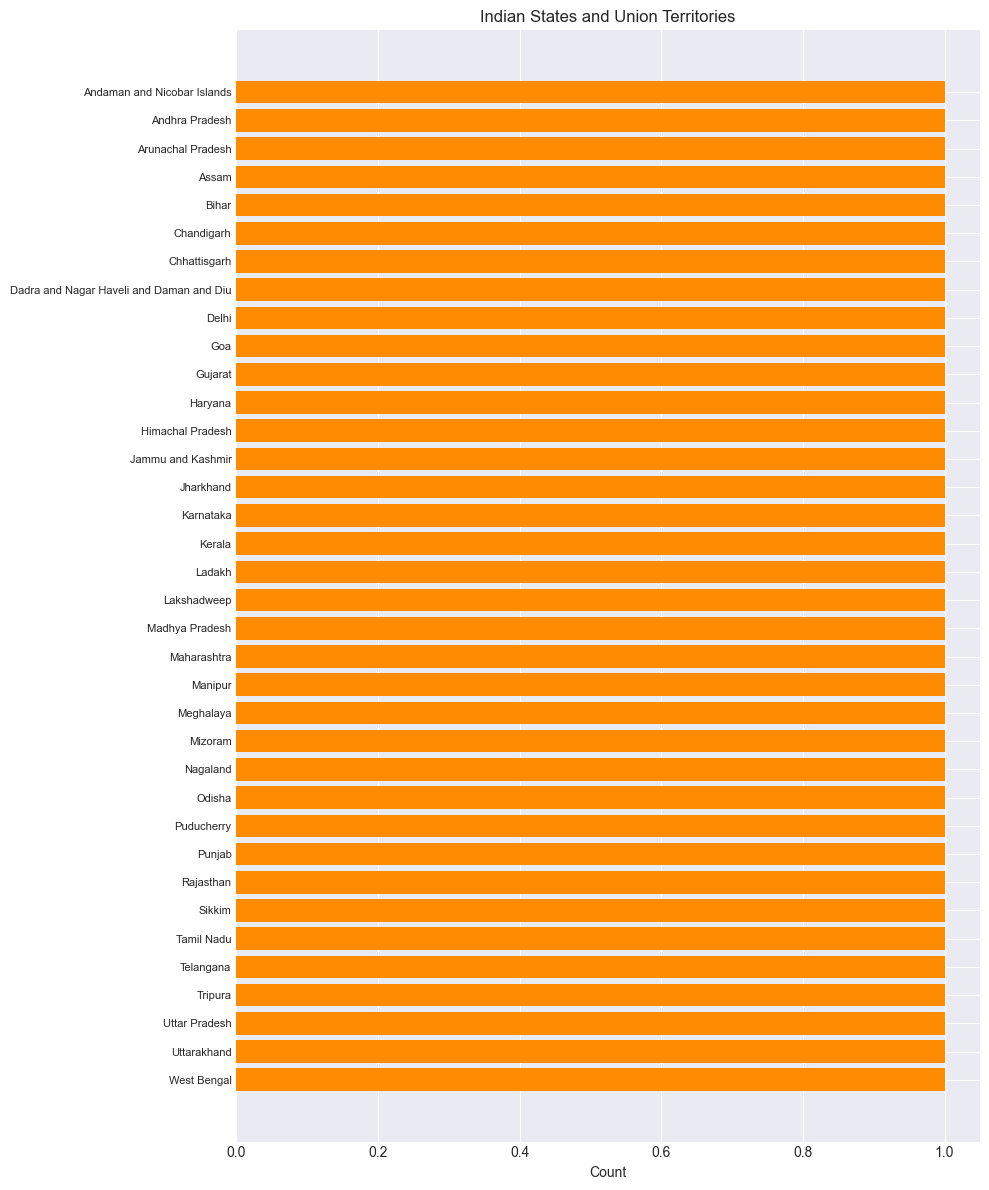

In [3]:
# List Indian states and union territories
states = idsp.list_states()
print(f"\n🇮🇳 Indian States and Union Territories ({len(states)} total):")
print(states.head(10).to_string(index=False))

# Visualize states
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(states))
ax.barh(y_pos, [1]*len(states), color='darkorange')
ax.set_yticks(y_pos)
ax.set_yticklabels(states['state_name'], fontsize=8)
ax.set_xlabel('Count')
ax.set_title('Indian States and Union Territories')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Explore Priority Diseases


🦠 Priority Diseases (29 total):

📊 Diseases by Syndrome Type:
  Syndromic (clinical diagnosis): 20 diseases
  Laboratory confirmed: 5 diseases
  Presumptive (clinical + epidemiological): 3 diseases
  Unusual event/syndrome: 1 diseases

📊 Diseases by Category:
  Epidemic-prone: 11 diseases
  Vector-borne: 8 diseases
  Seasonal: 3 diseases
  Routine: 3 diseases
  Lab-confirmed: 2 diseases
  Unknown: 1 diseases
  Pandemic: 1 diseases


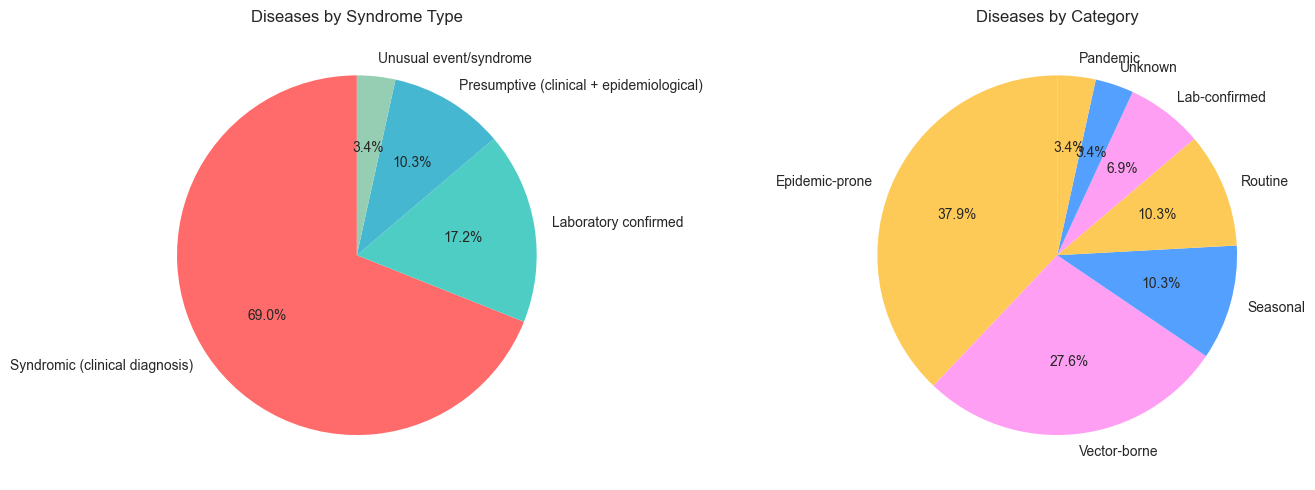

In [4]:
# List priority diseases
diseases = idsp.list_priority_diseases()
print(f"\n🦠 Priority Diseases ({len(diseases)} total):")

# Count by syndrome
syndrome_counts = diseases['syndrome_name'].value_counts()
print("\n📊 Diseases by Syndrome Type:")
for syndrome, count in syndrome_counts.items():
    print(f"  {syndrome}: {count} diseases")

# Count by category
category_counts = diseases['category'].value_counts()
print("\n📊 Diseases by Category:")
for category, count in category_counts.items():
    print(f"  {category}: {count} diseases")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Syndrome distribution
colors1 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax1.pie(syndrome_counts.values, labels=syndrome_counts.index, autopct='%1.1f%%',
        colors=colors1, startangle=90)
ax1.set_title('Diseases by Syndrome Type')

# Category distribution
colors2 = ['#FECA57', '#FF9FF3', '#54A0FF']
ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors2, startangle=90)
ax2.set_title('Diseases by Category')

plt.tight_layout()
plt.show()

## 5. Explore Disease Syndromes

In [5]:
# Explain syndrome classification
print("\n📋 IDSP Syndrome Classification (S/P/U/L):")
for code, name in idsp.SYNDROMES.items():
    print(f"  {code}: {name}")

# Show sample diseases by syndrome
print("\n🦠 Sample Diseases by Syndrome:")
for syndrome_code in ['S', 'P', 'L']:
    syndrome_name = idsp.SYNDROMES[syndrome_code]
    syndrome_diseases = diseases[diseases['syndrome_code'] == syndrome_code].head(5)
    print(f"\n{syndrome_code} - {syndrome_name}:")
    for _, row in syndrome_diseases.iterrows():
        print(f"  • {row['disease_code']} ({row['category']})")


📋 IDSP Syndrome Classification (S/P/U/L):
  S: Syndromic (clinical diagnosis)
  P: Presumptive (clinical + epidemiological)
  U: Unusual event/syndrome
  L: Laboratory confirmed

🦠 Sample Diseases by Syndrome:

S - Syndromic (clinical diagnosis):
  • Acute_Diarrhoeal_Disease (Epidemic-prone)
  • Bacillary_Dysentery (Epidemic-prone)
  • Viral_Hepatitis (Epidemic-prone)
  • Typhoid (Epidemic-prone)
  • Measles (Epidemic-prone)

P - Presumptive (clinical + epidemiological):
  • Influenza_Like_Illness (Seasonal)
  • Severe_Acute_Respiratory_Infection (Seasonal)
  • COVID_19 (Pandemic)

L - Laboratory confirmed:
  • Tuberculosis (Routine)
  • HIV_AIDS (Routine)
  • Leprosy (Routine)
  • Malaria_Lab (Lab-confirmed)
  • Typhoid_Lab (Lab-confirmed)


## 6. Fetch Outbreak Reports

In [6]:
# Query outbreak reports
selected_states = ['MH', 'KL', 'KA']  # Maharashtra, Kerala, Karnataka
selected_diseases = ['Dengue', 'Malaria', 'Acute_Diarrhoeal_Disease']

print(f"🔍 Querying outbreak reports:")
print(f"  States: {', '.join(selected_states)}")
print(f"  Diseases: {', '.join(selected_diseases)}")

outbreaks = idsp.get_outbreak_reports(
    years=[2023, 2024],
    states=selected_states,
    diseases=selected_diseases
)

if not outbreaks.empty:
    print(f"\n✅ Retrieved {len(outbreaks)} outbreak records")
    print("\n🔍 Sample data:")
    print(outbreaks.head())
    
    # Show structure
    print(f"\n📋 Columns: {list(outbreaks.columns)}")
else:
    print("\n⚠️ Outbreak data requires IDSP portal access")
    print("   Visit: https://idsp.nic.in/")

INFO:accessors.india_idsp:Fetching outbreak reports: years=[2023, 2024], states=['MH', 'KL', 'KA'], diseases=['Dengue', 'Malaria', 'Acute_Diarrhoeal_Disease']


🔍 Querying outbreak reports:
  States: MH, KL, KA
  Diseases: Dengue, Malaria, Acute_Diarrhoeal_Disease

✅ Retrieved 6 outbreak records

🔍 Sample data:
   year state_code   state_name outbreak_id disease_code cases_reported  \
0  2023         MH  Maharashtra        None       Dengue           None   
1  2023         KL       Kerala        None       Dengue           None   
2  2023         KA    Karnataka        None       Dengue           None   
3  2024         MH  Maharashtra        None       Dengue           None   
4  2024         KL       Kerala        None       Dengue           None   

  deaths_reported districts_affected start_date end_date status  \
0            None               None       None     None   None   
1            None               None       None     None   None   
2            None               None       None     None   None   
3            None               None       None     None   None   
4            None               None       None     None   Non

## 7. Disease Surveillance by State

In [7]:
# Query disease surveillance for specific diseases
print("📊 Fetching disease surveillance data...")

surveillance_data = idsp.get_disease_surveillance(
    disease="Dengue",
    states=['MH', 'KL', 'KA', 'TN', 'UP'],
    years=[2023, 2024]
)

if not surveillance_data.empty:
    print(f"✅ Retrieved {len(surveillance_data)} surveillance records")
    print("\n🔍 Sample data:")
    print(surveillance_data.head())
    
    # Compare across states
    print("\n📊 Surveillance by State:")
    for state in surveillance_data['state_code'].unique():
        state_name = surveillance_data[surveillance_data['state_code'] == state]['state_name'].iloc[0]
        print(f"  {state}: {state_name}")
else:
    print("\n⚠️ Surveillance data requires IDSP portal access")
    print("   Some diseases also available via NVBDCP: https://nvbdcp.gov.in/")

INFO:accessors.india_idsp:Fetching surveillance for Dengue: states=['MH', 'KL', 'KA', 'TN', 'UP'], years=[2023, 2024]


📊 Fetching disease surveillance data...
✅ Retrieved 10 surveillance records

🔍 Sample data:
   year state_code     state_name disease_code syndrome cases_total  \
0  2023         MH    Maharashtra       Dengue        S        None   
1  2023         KL         Kerala       Dengue        S        None   
2  2023         KA      Karnataka       Dengue        S        None   
3  2023         TN     Tamil Nadu       Dengue        S        None   
4  2023         UP  Uttar Pradesh       Dengue        S        None   

  deaths_total cases_lab_confirmed cases_presumptive cases_syndromic  \
0         None                None              None            None   
1         None                None              None            None   
2         None                None              None            None   
3         None                None              None            None   
4         None                None              None            None   

  reporting_units data_completeness             

## 8. Vector-Borne Disease Surveillance

INFO:accessors.india_idsp:Fetching VBD data: diseases=['Malaria', 'Dengue', 'Chikungunya', 'Japanese_Encephalitis']


🦟 Fetching Vector-Borne Disease data: Malaria, Dengue, Chikungunya, Japanese_Encephalitis
✅ Retrieved 8 VBD records

🔍 Sample data:
   year                disease cases deaths   api   spr    data_source  \
0  2023                Malaria  None   None  None  None  NVBDCP / IDSP   
1  2024                Malaria  None   None  None  None  NVBDCP / IDSP   
2  2023                 Dengue  None   None  None  None  NVBDCP / IDSP   
3  2024                 Dengue  None   None  None  None  NVBDCP / IDSP   
4  2023            Chikungunya  None   None  None  None  NVBDCP / IDSP   
5  2024            Chikungunya  None   None  None  None  NVBDCP / IDSP   
6  2023  Japanese_Encephalitis  None   None  None  None  NVBDCP / IDSP   
7  2024  Japanese_Encephalitis  None   None  None  None  NVBDCP / IDSP   

                                 note  
0  Data requires NVBDCP portal access  
1  Data requires NVBDCP portal access  
2  Data requires NVBDCP portal access  
3  Data requires NVBDCP portal access  
4

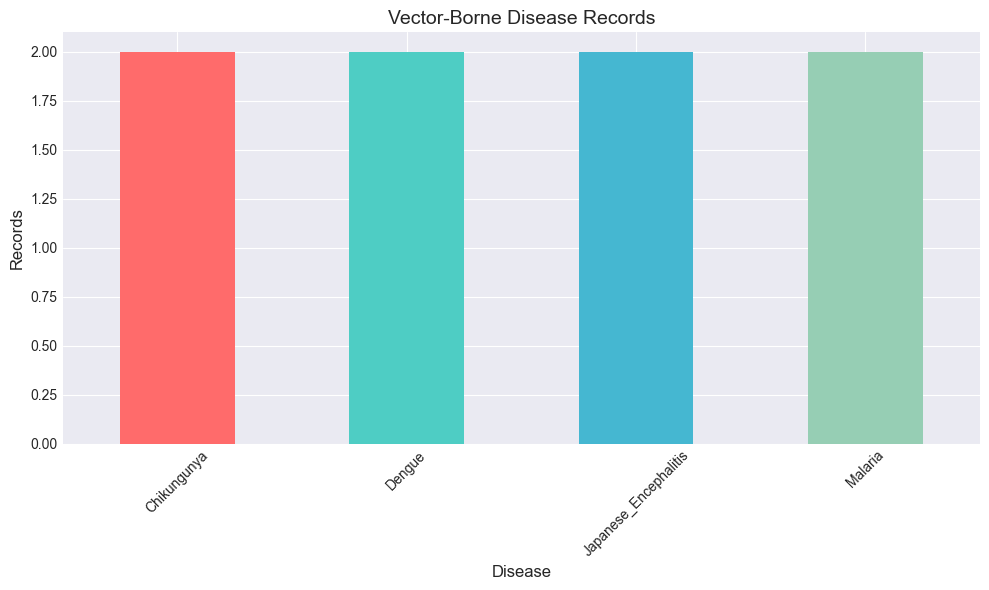

In [8]:
# Query vector-borne diseases
vbd_diseases = ['Malaria', 'Dengue', 'Chikungunya', 'Japanese_Encephalitis']
print(f"🦟 Fetching Vector-Borne Disease data: {', '.join(vbd_diseases)}")

vbd_data = idsp.get_vector_borne_diseases(
    diseases=vbd_diseases,
    years=[2023, 2024]
)

if not vbd_data.empty:
    print(f"✅ Retrieved {len(vbd_data)} VBD records")
    print("\n🔍 Sample data:")
    print(vbd_data)
    
    # Visualize VBD comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    disease_counts = vbd_data.groupby('disease').size()
    disease_counts.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    ax.set_xlabel('Disease', fontsize=12)
    ax.set_ylabel('Records', fontsize=12)
    ax.set_title('Vector-Borne Disease Records', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ VBD data requires NVBDCP portal access")
    print("   Visit: https://nvbdcp.gov.in/")

## 9. Weekly Surveillance Summary

In [9]:
# Get weekly surveillance summary
print("📅 Fetching weekly surveillance summary...")

weekly_summary = idsp.get_weekly_surveillance_summary(
    year=2024,
    week=10,
    state='MH'
)

if not weekly_summary.empty:
    print(f"✅ Retrieved {len(weekly_summary)} weekly summary records")
    print("\n🔍 Sample data:")
    print(weekly_summary.to_string(index=False))
    
    # Show reporting structure
    print("\n📋 IDSP Reporting Forms:")
    print("  • Form S: Syndromic (clinical diagnosis)")
    print("  • Form P: Presumptive (clinical + epidemiological)")
    print("  • Form L: Laboratory confirmed")
    print("  • Form U: Unusual events/syndromes")
else:
    print("\n⚠️ Weekly data requires IDSP portal access")

INFO:accessors.india_idsp:Fetching weekly summary for 2024 week 10, state=MH


📅 Fetching weekly surveillance summary...
✅ Retrieved 10 weekly summary records

🔍 Sample data:
 year  week state                disease_code syndromic_cases presumptive_cases lab_confirmed_cases deaths reporting_units               data_source                             note
 2024    10    MH    Acute_Diarrhoeal_Disease            None              None                None   None            None IDSP Weekly S/P/L Reports Data requires IDSP portal access
 2024    10    MH         Bacillary_Dysentery            None              None                None   None            None IDSP Weekly S/P/L Reports Data requires IDSP portal access
 2024    10    MH             Viral_Hepatitis            None              None                None   None            None IDSP Weekly S/P/L Reports Data requires IDSP portal access
 2024    10    MH                     Typhoid            None              None                None   None            None IDSP Weekly S/P/L Reports Data requires IDSP portal a

## 10. Seasonal Patterns

INFO:accessors.india_idsp:Analyzing seasonal patterns for Dengue


🌡️ Analyzing seasonal disease patterns...
✅ Retrieved 36 seasonal records

🔍 Sample data:
   year  month disease cases expected_cases alert_threshold  \
0  2022      1  Dengue  None           None            None   
1  2022      2  Dengue  None           None            None   
2  2022      3  Dengue  None           None            None   
3  2022      4  Dengue  None           None            None   
4  2022      5  Dengue  None           None            None   

  epidemic_threshold               data_source  \
0               None  IDSP Historical Analysis   
1               None  IDSP Historical Analysis   
2               None  IDSP Historical Analysis   
3               None  IDSP Historical Analysis   
4               None  IDSP Historical Analysis   

                                         note  
0  Seasonal analysis requires historical data  
1  Seasonal analysis requires historical data  
2  Seasonal analysis requires historical data  
3  Seasonal analysis requires historic

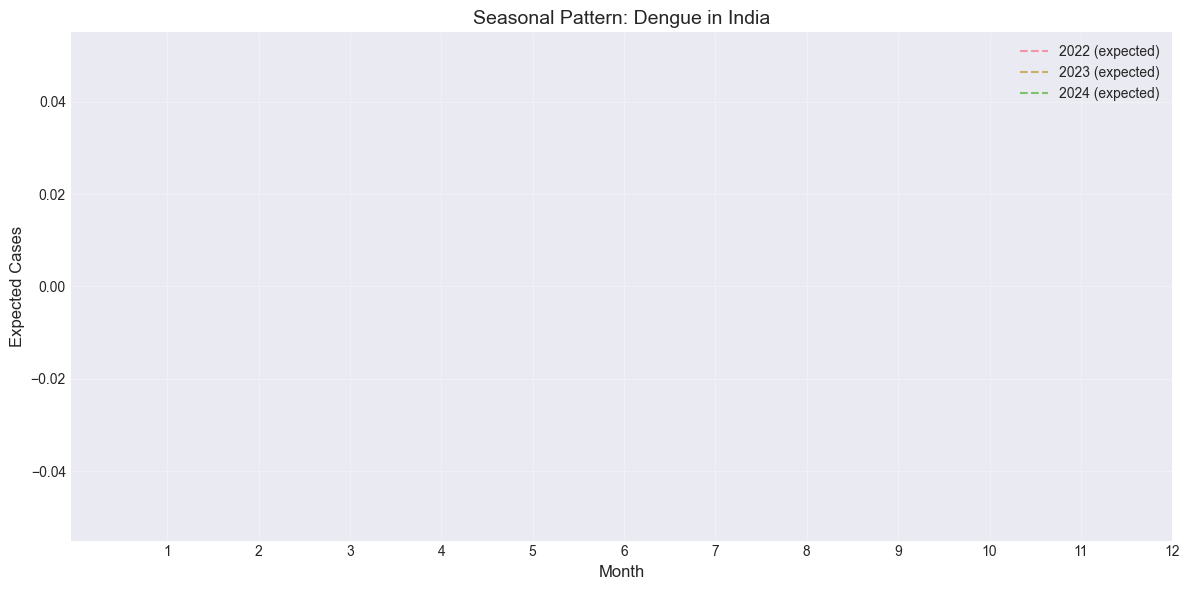


📊 Seasonal Insights:
  • Peak months typically: July-October (post-monsoon)
  • Lowest activity: December-March (cool/dry season)


In [10]:
# Analyze seasonal patterns
print("🌡️ Analyzing seasonal disease patterns...")

seasonal = idsp.get_seasonal_patterns(
    disease="Dengue",
    years=[2022, 2023, 2024]
)

if not seasonal.empty:
    print(f"✅ Retrieved {len(seasonal)} seasonal records")
    print("\n🔍 Sample data:")
    print(seasonal.head())
    
    # Visualize seasonal pattern
    fig, ax = plt.subplots(figsize=(12, 6))
    for year in seasonal['year'].unique():
        year_data = seasonal[seasonal['year'] == year]
        ax.plot(year_data['month'], year_data['expected_cases'], 
                label=f'{year} (expected)', linestyle='--', alpha=0.7)
    
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Expected Cases', fontsize=12)
    ax.set_title('Seasonal Pattern: Dengue in India', fontsize=14)
    ax.legend()
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Seasonal Insights:")
    print("  • Peak months typically: July-October (post-monsoon)")
    print("  • Lowest activity: December-March (cool/dry season)")

## 11. State Comparison

INFO:accessors.india_idsp:Comparing Dengue across states for 2024


📊 Comparing disease burden across states...
✅ Retrieved comparison for 10 states

🔍 Sample data:
state_code                               state_name  year disease cases deaths incidence_per_100k population rank data_source                                 note
        AN              Andaman and Nicobar Islands  2024  Dengue  None   None               None       None None        IDSP Comparison requires data aggregation
        AP                           Andhra Pradesh  2024  Dengue  None   None               None       None None        IDSP Comparison requires data aggregation
        AR                        Arunachal Pradesh  2024  Dengue  None   None               None       None None        IDSP Comparison requires data aggregation
        AS                                    Assam  2024  Dengue  None   None               None       None None        IDSP Comparison requires data aggregation
        BR                                    Bihar  2024  Dengue  None   None          

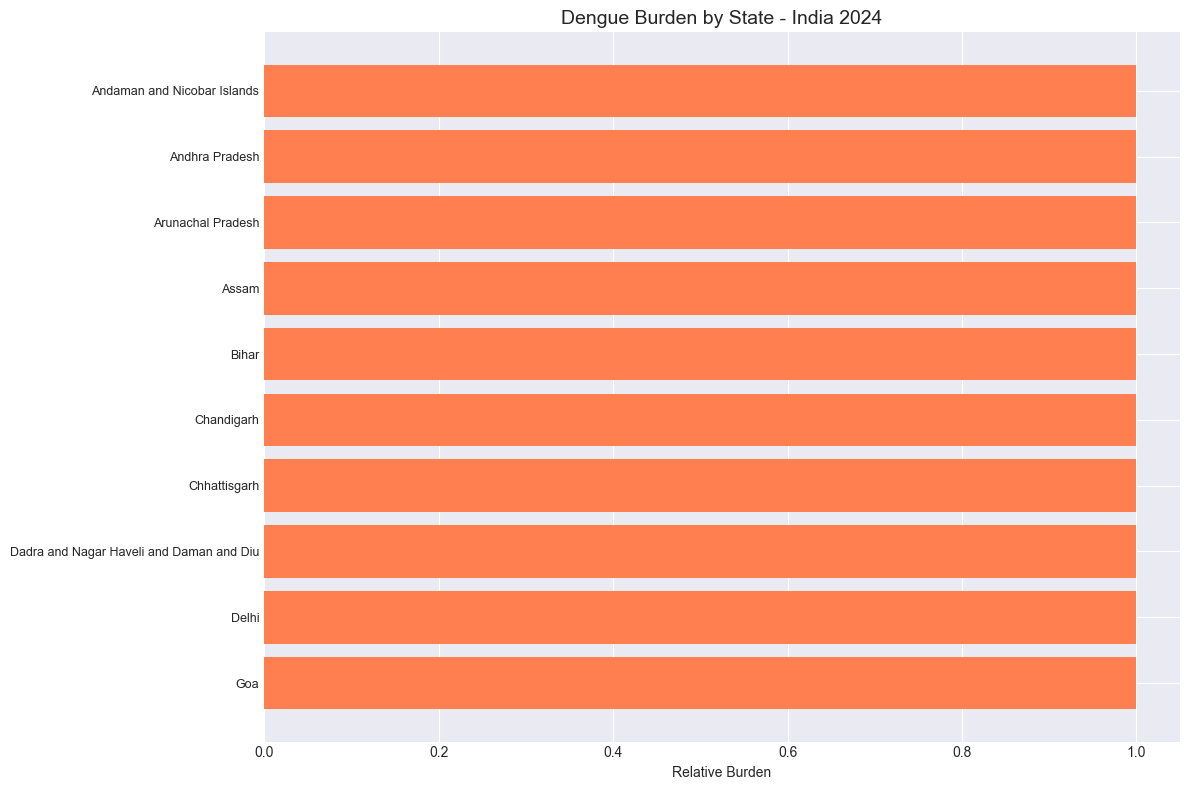

In [11]:
# Compare disease burden across states
print("📊 Comparing disease burden across states...")

state_comparison = idsp.get_state_comparison(
    disease="Dengue",
    year=2024,
    metric="cases"
)

if not state_comparison.empty:
    print(f"✅ Retrieved comparison for {len(state_comparison)} states")
    print("\n🔍 Sample data:")
    print(state_comparison.head(10).to_string(index=False))
    
    # Visualize state comparison
    fig, ax = plt.subplots(figsize=(12, 8))
    state_data = state_comparison.head(15)  # Top 15 states
    y_pos = range(len(state_data))
    ax.barh(y_pos, [1]*len(state_data), color='coral')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(state_data['state_name'], fontsize=9)
    ax.set_xlabel('Relative Burden')
    ax.set_title('Dengue Burden by State - India 2024', fontsize=14)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 12. Summary Dashboard

In [12]:
# Create a summary dashboard
print("="*60)
print("🇮🇳 INDIA IDSP SURVEILLANCE DATA SUMMARY")
print("="*60)

print("\n🌏 Coverage:")
print(f"  • States/Union Territories: {len(idsp.STATES)}")
print(f"  • Priority Diseases: {len(idsp.PRIORITY_DISEASES)}")
print(f"  • Reporting Forms: S (Syndromic), P (Presumptive), L (Lab), U (Unusual)")

print("\n🦠 Priority Disease Categories:")
for category in ['Epidemic-prone', 'Vector-borne', 'Routine', 'Seasonal']:
    cat_count = len(diseases[diseases['category'] == category])
    print(f"  • {category}: {cat_count} diseases")

print("\n📈 Key Vector-Borne Diseases:")
vbd_list = ['Malaria', 'Dengue', 'Chikungunya', 'Japanese_Encephalitis', 'Kala_Azar']
for disease in vbd_list:
    print(f"  • {disease}")

print("\n🌐 Data Sources:")
print(f"  • IDSP Portal: {idsp.IDSP_URL}")
print(f"  • NVBDCP: {idsp.NVBDCP_URL}")
print(f"  • NACO (HIV/AIDS): {idsp.NACO_URL}")

print("\n💡 Usage Examples:")
print("  idsp = IndiaIDSPAccessor()")
print("  outbreaks = idsp.get_outbreak_reports(")
print("      years=[2024], states=['MH', 'KL']")
print("  )")
print("  dengue = idsp.get_disease_surveillance(")
print("      disease='Dengue',")
print("      states=['KA', 'TN', 'KL']")
print("  )")
print("  vbd = idsp.get_vector_borne_diseases(")
print("      diseases=['Malaria', 'Dengue']")
print("  )")

print("\n✅ India IDSP accessor ready to use!")
print("="*60)

🇮🇳 INDIA IDSP SURVEILLANCE DATA SUMMARY

🌏 Coverage:
  • States/Union Territories: 36
  • Priority Diseases: 29
  • Reporting Forms: S (Syndromic), P (Presumptive), L (Lab), U (Unusual)

🦠 Priority Disease Categories:
  • Epidemic-prone: 11 diseases
  • Vector-borne: 8 diseases
  • Routine: 3 diseases
  • Seasonal: 3 diseases

📈 Key Vector-Borne Diseases:
  • Malaria
  • Dengue
  • Chikungunya
  • Japanese_Encephalitis
  • Kala_Azar

🌐 Data Sources:
  • IDSP Portal: https://idsp.nic.in
  • NVBDCP: https://nvbdcp.gov.in
  • NACO (HIV/AIDS): http://naco.gov.in

💡 Usage Examples:
  idsp = IndiaIDSPAccessor()
  outbreaks = idsp.get_outbreak_reports(
      years=[2024], states=['MH', 'KL']
  )
  dengue = idsp.get_disease_surveillance(
      disease='Dengue',
      states=['KA', 'TN', 'KL']
  )
  vbd = idsp.get_vector_borne_diseases(
      diseases=['Malaria', 'Dengue']
  )

✅ India IDSP accessor ready to use!


## 13. Data Export

In [ ]:
# Export data to CSV (optional)
export_path = "./india_idsp_export/"
import os
os.makedirs(export_path, exist_ok=True)

# Export states
states.to_csv(f"{export_path}india_states.csv", index=False)
print(f"✅ Exported states to {export_path}india_states.csv")

# Export diseases
diseases.to_csv(f"{export_path}india_priority_diseases.csv", index=False)
print(f"✅ Exported diseases to {export_path}india_priority_diseases.csv")

print(f"\n📁 All exports saved to: {os.path.abspath(export_path)}")

print("\n📋 Next Steps:")
print("  1. Visit IDSP portal for detailed outbreak reports")
print("  2. Check NVBDCP for vector-borne disease data")
print("  3. Explore weekly surveillance summaries")
print("  4. Analyze seasonal patterns for key diseases")